## DATASET INDODISCOURSE_ANNOTATOR

In [1]:
# Import Library
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
# Input dataset
df = pd.read_csv("D:/SDT/Project Sistem Cerdas/Project-Intelligence-System/data/raw/indodiscourse_annotator.csv")
PLOT_DIR = "eda_annotator_plots"
os.makedirs(PLOT_DIR, exist_ok=True)


In [3]:
## CLEANING DATA
# 1. Rapikan nama kolom (ganti spasi -> underscore, biar bisa dipanggil df.kolom)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
# 2. Trim whitespace di semua kolom string (mis. "M " -> "M", "Mataram " -> "Mataram")
str_cols = df.select_dtypes(include="object").columns
for c in str_cols:
    df[c] = df[c].str.strip()

# 3. Mengubah '-', 'Golput' menjadi angka 0 
df["president_vote_leaning"] = df["president_vote_leaning"].replace({"-": "0", "Golput": "0"})
df["president_vote_leaning"] = df["president_vote_leaning"].astype(int)

# 4. Menyamakan kategori Bali dan Balinese
df["ethnicity"] = df["ethnicity"].replace("Balinese", "Bali")

COLUMN_MEANING = {
    "annotator_id": "ID unik annotator (dipakai untuk join ke dataset teks via annotators_id)",
    "ethnicity": "Suku/etnis annotator",
    "religion": "Agama/kepercayaan annotator",
    "disability": "Status disabilitas (yes/no)",
    "lgbt": "Identifikasi sebagai bagian komunitas LGBT (yes/no)",
    "gender": "Jenis kelamin (F/M)",
    "age": "Usia annotator (tahun)",
    "domisili": "Kota domisili annotator",
    "pendidikan_terakhir": "Jenjang pendidikan terakhir",
    "status_pekerjaan": "Status pekerjaan saat ini",
    "president_vote_leaning": "Kecenderungan pilihan capres 2024 (kode paslon 1/2/3, atau Golput)",
}

In [4]:
## STRUKTUR DATASET
print("-"*72)
print("A. STRUKTUR DATASET")
print("-"*72)
print(f"Jumlah baris (annotator) : {len(df)}")
print(f"Jumlah kolom             : {df.shape[1]}")
print(f"Rentang annotator_id     : {df['annotator_id'].min()}-{df['annotator_id'].max()}")

print("\nNama kolom & tipe data:")
for col in df.columns:
    print(f"  - {col:24s}: {df[col].dtype}")

print("\nArti setiap kolom:")
for col, meaning in COLUMN_MEANING.items():
    print(f"  - {col:24s}: {meaning}")

------------------------------------------------------------------------
A. STRUKTUR DATASET
------------------------------------------------------------------------
Jumlah baris (annotator) : 29
Jumlah kolom             : 11
Rentang annotator_id     : 1-31

Nama kolom & tipe data:
  - annotator_id            : int64
  - ethnicity               : object
  - religion                : object
  - disability              : object
  - lgbt                    : object
  - gender                  : object
  - age                     : int64
  - domisili                : object
  - pendidikan_terakhir     : object
  - status_pekerjaan        : object
  - president_vote_leaning  : int64

Arti setiap kolom:
  - annotator_id            : ID unik annotator (dipakai untuk join ke dataset teks via annotators_id)
  - ethnicity               : Suku/etnis annotator
  - religion                : Agama/kepercayaan annotator
  - disability              : Status disabilitas (yes/no)
  - lgbt               

In [5]:
## KUALITAS DATA
print("\n" + "-"*72)
print("B. KUALITAS DATA")
print("-"*72)

# Missing / placeholder value ---
print("\n Missing value per kolom (setelah '-' dan 'Golput' digabung jadi 0 di president_vote_leaning):")
print(df.isnull().sum().to_string())


------------------------------------------------------------------------
B. KUALITAS DATA
------------------------------------------------------------------------

 Missing value per kolom (setelah '-' dan 'Golput' digabung jadi 0 di president_vote_leaning):
annotator_id              0
ethnicity                 0
religion                  0
disability                0
lgbt                      0
gender                    0
age                       0
domisili                  0
pendidikan_terakhir       0
status_pekerjaan          0
president_vote_leaning    0


In [6]:
# Duplikasi
print(f"\nDuplikat annotator_id : {df['annotator_id'].duplicated().sum()}")
print(f"Duplikat baris penuh  : {df.duplicated().sum()}")

missing_ids = set(range(df["annotator_id"].min(), df["annotator_id"].max() + 1)) - set(df["annotator_id"])
print(f"ID yang hilang dari rentang berurutan: {sorted(missing_ids)} "
      f"(kemungkinan annotator yang dikeluarkan dari studi, bukan error)")


Duplikat annotator_id : 0
Duplikat baris penuh  : 0
ID yang hilang dari rentang berurutan: [14, 17] (kemungkinan annotator yang dikeluarkan dari studi, bukan error)


In [7]:
# Inkonsistensi kategori (ejaan/penamaan beda untuk nilai yang sama)
print("\nNilai unik per kolom kategorikal (cek manual inkonsistensi penamaan):")
cat_cols = ["ethnicity", "religion", "disability", "lgbt", "gender",
            "domisili", "pendidikan_terakhir", "status_pekerjaan", "president_vote_leaning"]
for col in cat_cols:
    print(f"  {col:24s}: {sorted(df[col].dropna().unique())}")


Nilai unik per kolom kategorikal (cek manual inkonsistensi penamaan):
  ethnicity               : ['Aceh', 'Arab', 'Bali', 'Batak', 'Bugis', 'Dayak', 'Jawa', 'Madura', 'Melayu', 'Minang', 'Sasak', 'Sunda', 'Ternate', 'Tionghoa', 'Tobelo']
  religion                : ['Ahmadiyah', 'Buddha', 'Hindu', 'Islam', 'Katolik', 'Kepercayaan Lokal', 'Kristen', 'Syiah']
  disability              : ['no', 'yes']
  lgbt                    : ['no', 'yes']
  gender                  : ['F', 'M']
  domisili                : ['Banda Aceh', 'Bandung', 'Bogor', 'Depok', 'Jakarta', 'Madura', 'Magelang', 'Makassar', 'Mataram', 'Medan', 'Padang', 'Pontianak', 'Riau', 'Sumedang', 'Tangerang', 'Ternate']
  pendidikan_terakhir     : ['Diploma', 'Doktor (S3)', 'Magister (S2)', 'Sarjana (S1)', 'Sekolah Menengah Atas (SMA)']
  status_pekerjaan        : ['Bekerja', 'Ibu Rumah Tangga', 'Pelajar/Mahasiswa', 'Tidak Bekerja']
  president_vote_leaning  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]



Distribusi usia annotator:
count    29.000000
mean     32.172414
std      10.142094
min      19.000000
25%      23.000000
50%      32.000000
75%      39.000000
max      59.000000

Ketidakseimbangan representasi demografi (n=29 annotator, sample kecil):
  gender                  : {'F': 16, 'M': 13}  (kategori dominan: 55.2%)
  religion                : {'Islam': 18, 'Hindu': 3, 'Kristen': 2, 'Katolik': 2, 'Kepercayaan Lokal': 1, 'Syiah': 1, 'Ahmadiyah': 1, 'Buddha': 1}  (kategori dominan: 62.1%)
  ethnicity               : {'Sunda': 4, 'Minang': 3, 'Tionghoa': 3, 'Bugis': 3, 'Bali': 3, 'Jawa': 2, 'Batak': 2, 'Aceh': 2, 'Madura': 1, 'Arab': 1, 'Melayu': 1, 'Dayak': 1, 'Ternate': 1, 'Sasak': 1, 'Tobelo': 1}  (kategori dominan: 13.8%)
  disability              : {'no': 26, 'yes': 3}  (kategori dominan: 89.7%)
  lgbt                    : {'no': 28, 'yes': 1}  (kategori dominan: 96.6%)
  pendidikan_terakhir     : {'Sarjana (S1)': 12, 'Sekolah Menengah Atas (SMA)': 8, 'Magister (S2)': 6, 'D

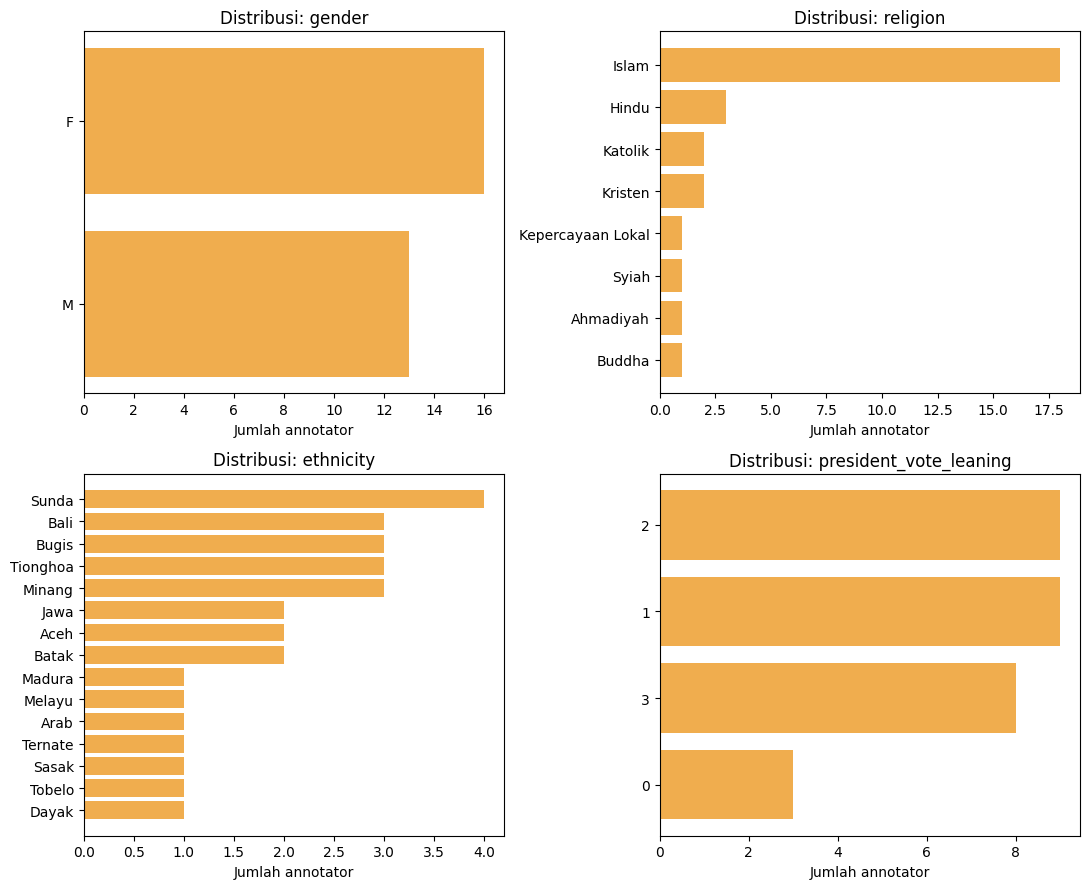

In [8]:
# Distribusi usia
print("\nDistribusi usia annotator:")
print(df["age"].describe().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["age"], bins=12, color="#5bc0de", edgecolor="white")
ax.axvline(df["age"].median(), color="red", linestyle="--", label=f"Median = {df['age'].median():.0f}")
ax.set_xlabel("Usia")
ax.set_ylabel("Jumlah annotator")
ax.set_title("Distribusi Usia Annotator")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_age_distribution.png", dpi=150)
plt.close()

# Ketidakseimbangan kelas demografi
print("\nKetidakseimbangan representasi demografi (n=29 annotator, sample kecil):")
for col in ["gender", "religion", "ethnicity", "disability", "lgbt",
            "pendidikan_terakhir", "status_pekerjaan", "president_vote_leaning"]:
    counts = df[col].value_counts(dropna=True)
    pct_top = counts.iloc[0] / counts.sum() * 100
    print(f"  {col:24s}: {counts.to_dict()}  (kategori dominan: {pct_top:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_cols = ["gender", "religion", "ethnicity", "president_vote_leaning"]
for ax, col in zip(axes.flat, plot_cols):
    counts = df[col].value_counts(dropna=True).sort_values()
    ax.barh(counts.index.astype(str), counts.values, color="#f0ad4e")
    ax.set_title(f"Distribusi: {col}")
    ax.set_xlabel("Jumlah annotator")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_demographic_balance.png", dpi=150)
plt.show()